# Multi-tissue classification Ovarian cancer

**Table of Contents**                                                                      
Step1: Environment Setup                                                                          
Step2: Data Loading and Preparation                                                                      
Step3: Analyzing Class Distribution                                                          
Step4: Data Augmentation                                                           
Step5: Splitting the Dataset                                                                                     
Step6: Preparing Data Generators                                                             
Step7: Building the Model                                                                                       
Step8: Compiling the Model                                                 
Step9: Implementing Learning Rate Scheduling and Early Stopping                                      
Step10: Training the Model                                                             
Step11: Evaluating the Model                                                                   
Step12: Conclusion and Next Steps                                                           



**Step: 1 Environment Setup**

In [15]:
# Data manipulation and analysis
import os 
import numpy as np
import pandas as pd
from glob import glob

# Image processing
from PIL import Image
import cv2


# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, MaxPool2D, Input
from tensorflow.keras.layers import Layer, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.layers import Input, Embedding, Concatenate
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input



# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Loading Data**


In [5]:
# Assuming the dataset is in a folder named 'dataset'
data_dir = '/kaggle/input/tcga-ovarian-histological-images/ovarian'

# Get class names from subdirectory names
classes = sorted([d.name for d in os.scandir(data_dir) if d.is_dir()])
print("Classes:", classes)


# Initialize lists to hold file paths and labels
image_paths = []
image_labels = []

# Map class names to numerical labels
class_to_label = {class_name: idx for idx, class_name in enumerate(classes)}
print("Class to label mapping:", class_to_label)

# Loop through each class directory and collect file paths
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    # Get all image file paths in the class directory
    image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith('.jpg')]
    # Append file paths and labels
    image_paths.extend(image_files)
    image_labels.extend([class_to_label[class_name]] * len(image_files))
    #print(f"Processing {len(image_files)} images for class '{class_name}'")

print(f"Total images found: {len(image_paths)}")

Classes: ['non-tumour', 'tumour']
Class to label mapping: {'non-tumour': 0, 'tumour': 1}
Total images found: 33110


**3. Analyzing Class Distribution**

Class counts:
 class_name
tumour        19747
non-tumour    13363
Name: count, dtype: int64


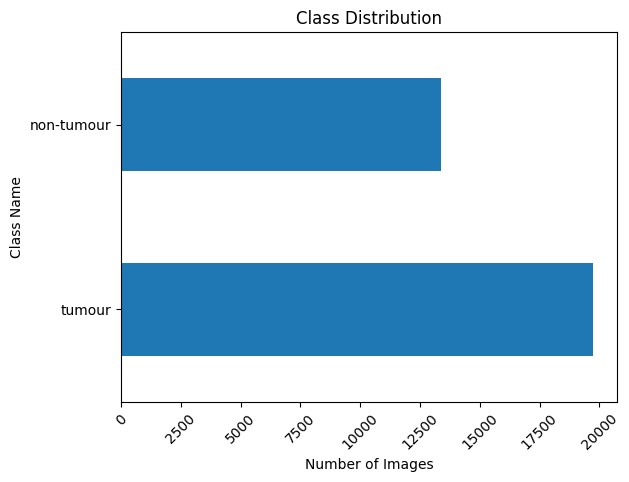

In [6]:
# Create a DataFrame to aid in analysis
df = pd.DataFrame({
    'image_path': image_paths,
    'label': image_labels
})

# Map numerical labels to class names
label_to_class = {v: k for k, v in class_to_label.items()}
df['class_name'] = df['label'].map(label_to_class)

# Display class counts
class_counts = df['class_name'].value_counts()
print("Class counts:\n", class_counts)

# Plot class distribution
class_counts.plot(kind='barh')
plt.title('Class Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.xticks(rotation=45)
plt.show() 



In [7]:
df.head()

,image_path,label,class_name
0,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
1,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
2,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
3,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour
4,/kaggle/input/tcga-ovarian-histological-images...,0,non-tumour


In [8]:
df.tail()

,image_path,label,class_name
33105,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33106,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33107,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33108,/kaggle/input/tcga-ovarian-histological-images...,1,tumour
33109,/kaggle/input/tcga-ovarian-histological-images...,1,tumour


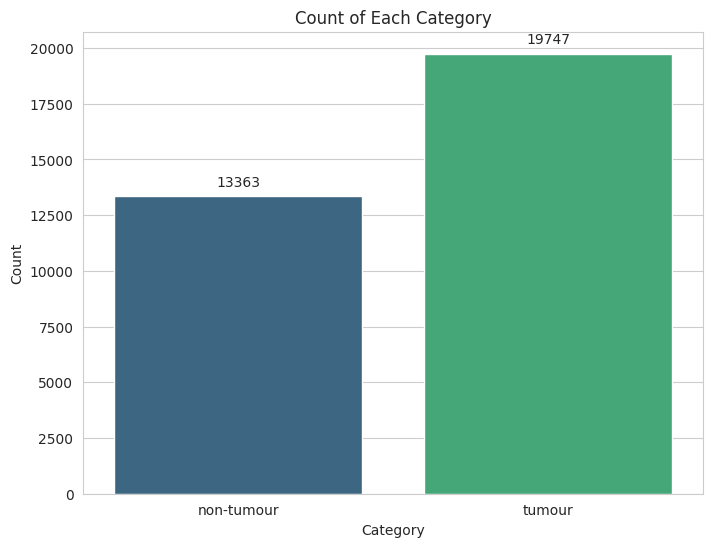

In [9]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

ax = sns.countplot(data=df, x=df['label'].map(label_to_class), palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center',
                va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points')

plt.title("Count of Each Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

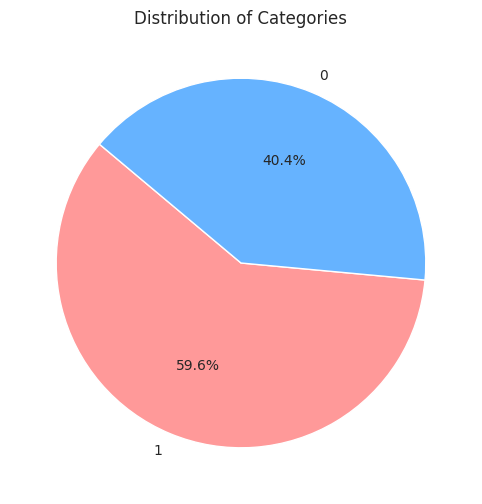

In [10]:
#Show distribution of classes in pye chart
label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])

plt.title("Distribution of Categories")

plt.show() 

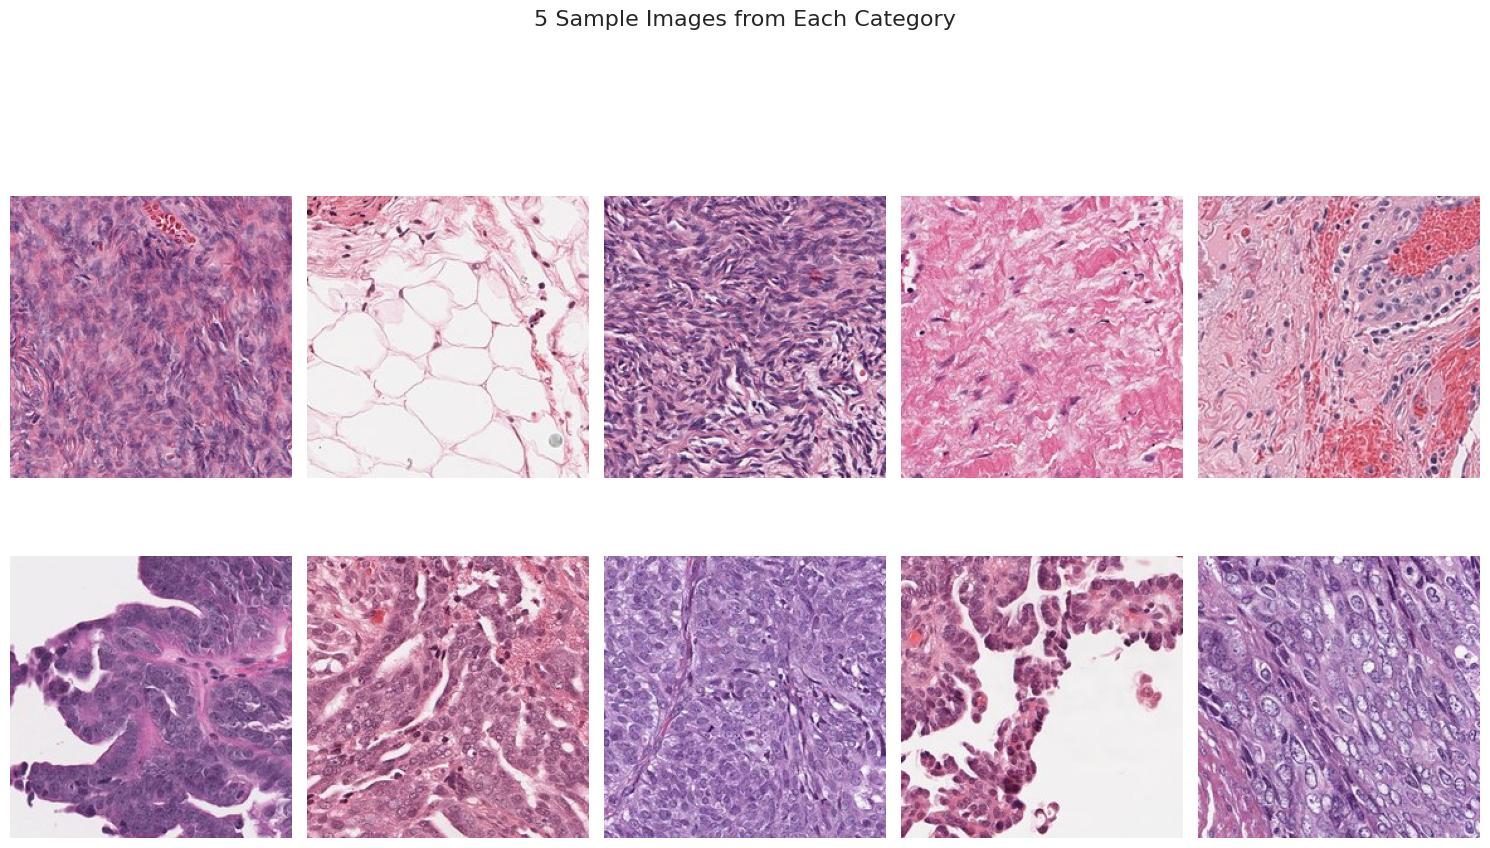

In [11]:
num_images = 5

fig, axes = plt.subplots(len(label_to_class), num_images, figsize=(15, 10))
fig.suptitle("5 Sample Images from Each Category", fontsize=16)

for i, category in enumerate(label_to_class):

    sample_images = df[df['label'] == category].sample(num_images)

    for j, image_path in enumerate(sample_images['image_path']):

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(category, fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
     


**Step 5: Split the Dataset**


In [12]:
# Split into training and temp (validation + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42,
    shuffle = True
)

# Split temp into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42,
    shuffle = True
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")




Training set size: 26488
Validation set size: 3311
Test set size: 3311


**6. Preparing Data Generators**


6.1. Training Data Generator


In [13]:
batch_size = 64
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='class_name',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)



Found 26488 validated image filenames belonging to 2 classes.


6.2. Validation Data Generator

In [14]:
valid_gen_new = ts_gen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='class_name',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
    
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='class_name',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
    
)

Found 3311 validated image filenames belonging to 2 classes.
Found 3311 validated image filenames belonging to 2 classes.


**9. Building and Configuring the InceptionResNetV2 Model**

In [32]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

class Patches(Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        # Extract patches from the images
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size,1],
            rates=[1,1,1,1],
            padding='VALID'
        )
        patch_dims = patches.shape[-1]
        num_patches = patches.shape[1] * patches.shape[2]
        # Reshape the patches to (batch_size, num_patches, patch_dims)
        patches = tf.reshape(patches, [batch_size, num_patches, patch_dims])
        return patches


class ClassToken(Layer):
    def __init__(self):
        super(ClassToken, self).__init__()

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(1,1,input_shape[-1]),
            initializer='random_normal',
            trainable=True)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        cls = tf.broadcast_to(self.w, [batch_size, 1, inputs.shape[-1]])
        return cls


def mlp(x, cf):
    x = Dense(cf["mlp_dim"], activation="gelu")(x)
    x = Dropout(cf["dropout_rate"])(x)
    x = Dense(cf["hidden_dim"])(x)
    x = Dropout(cf["dropout_rate"])(x)
    return x


def transformer_encoder(x, cf):
    # Layer Norm 1
    x1 = LayerNormalization(epsilon=1e-6)(x)
    # Multi-Head Attention
    attention_output = MultiHeadAttention(
        num_heads=cf["num_heads"], key_dim=cf["hidden_dim"]
    )(x1, x1)
    # Skip Connection 1
    x2 = Add()([attention_output, x])

    # Layer Norm 2
    x3 = LayerNormalization(epsilon=1e-6)(x2)
    # MLP
    mlp_output = mlp(x3, cf)
    # Skip Connection 2
    x4 = Add()([mlp_output, x2])

    return x4


def ViT(cf):
    """ Inputs """
    input_shape = (cf["image_size"], cf["image_size"], cf["num_channels"])
    inputs = Input(shape=input_shape)  # (None, 224, 224, 3)

    """ Create Patches """
    patches = Patches(cf["patch_size"])(inputs)
    num_patches = (cf["image_size"] // cf["patch_size"]) ** 2
    patch_dims = patches.shape[-1]

    """ Patch + Position Embeddings """
    # Project the patches
    x = Dense(cf["hidden_dim"])(patches)

    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_embed = Embedding(input_dim=num_patches, output_dim=cf["hidden_dim"])(positions)
    pos_embed = pos_embed[tf.newaxis, ...]

    # Add position embedding
    embed = x + pos_embed

    """ Adding Class Token """
    cls_token = ClassToken()(embed)
    x = Concatenate(axis=1)([cls_token, embed])  # (batch_size, num_patches + 1, hidden_dim)

    """ Transformer Encoder """
    for _ in range(cf["num_layers"]):
        x = transformer_encoder(x, cf)

    """ Classification Head """
    x = LayerNormalization(epsilon=1e-6)(x)
    x = x[:, 0, :]  # Extract the class token
    x = Dropout(cf["dropout_rate"])(x)
    outputs = Dense(cf["num_classes"], activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


if __name__ == "__main__":
    config = {}
    config["num_layers"] = 12            # Number of Transformer blocks
    config["hidden_dim"] = 768           # Hidden size of the Transformer
    config["mlp_dim"] = 3072             # MLP intermediate size
    config["num_heads"] = 12             # Number of attention heads
    config["dropout_rate"] = 0.1         # Dropout rate
    config["image_size"] = 224           # Size of the input images
    config["patch_size"] = 64            # Size of the patches
    config["num_channels"] = 3           # Number of image channels
    config["num_classes"] = 2            # Number of output classes

    model = ViT(config)
    model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ patches_1 (Patches)       │ (None, 9, 12288)       │              0 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_133 (Dense)         │ (None, 9, 768)         │      9,437,952 │ patches_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_128 (Add)             │ (None, 9, 768)         │              0 │ dense_133[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ class_token_7             │ (None, 1, 768)         │            768 │ add_128[0][0]          │
│ (ClassToken)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_7             │ (None, 10, 768)        │              0 │ class_token_7[0][0],   │
│ (Concatenate)             │                        │                │ add_128[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_125   │ (None, 10, 768)        │          1,536 │ concatenate_7[0][0]    │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_60   │ (None, 10, 768)        │     28,339,968 │ layer_normalization_1… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_129 (Add)             │ (None, 10, 768)        │              0 │ multi_head_attention_… │
│                           │                        │                │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_126   │ (None, 10, 768)        │          1,536 │ add_129[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_134 (Dense)         │ (None, 10, 3072)       │      2,362,368 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_186 (Dropout)     │ (None, 10, 3072)       │              0 │ dense_134[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_135 (Dense)         │ (None, 10, 768)        │      2,360,064 │ dropout_186[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_187 (Dropout)     │ (None, 10, 768)        │              0 │ dense_135[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_130 (Add)             │ (None, 10, 768)        │              0 │ dropout_187[0][0],     │
│                           │                        │                │ add_129[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1

 Total params: 406,227,458 (1.51 GB)

 Trainable params: 406,227,458 (1.51 GB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Compile the model
#tf.keras.losses.binary_crossentropy
#model.compile(optimizer= 'adam' , loss=  tf.keras.losses.SparseCategoricalCrossentropy, metrics=['accuracy']) 
optimizer = Adam(0.0001)
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [34]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=5,
    verbose=0,
    mode="auto",
    min_delta=0.0001,
    cooldown=0,
    min_lr=0.0,
)

callbacks = [early_stopping, reduce_lr]

Step 7: Cross-validating model        


In [35]:
steps_per_epoch = len(train_df) *2 // batch_size  # Oversampling will effectively double the data
# Train the model
history = model.fit(
    train_gen_new,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data= valid_gen_new,  #(X_val, y_val),
    #class_weight=class_weights,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


414/827 ━━━━━━━━━━━━━━━━━━━━ 5:22 781ms/step - accuracy: 0.6263 - loss: 1.1623

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


827/827 ━━━━━━━━━━━━━━━━━━━━ 435s 446ms/step - accuracy: 0.6723 - loss: 0.9122 - val_accuracy: 0.8215 - val_loss: 0.4152 - learning_rate: 1.0000e-04
Epoch 2/30
827/827 ━━━━━━━━━━━━━━━━━━━━ 308s 370ms/step - accuracy: 0.8109 - loss: 0.4313 - val_accuracy: 0.7113 - val_loss: 0.5787 - learning_rate: 1.0000e-04
Epoch 3/30
827/827 ━━━━━━━━━━━━━━━━━━━━ 307s 370ms/step - accuracy: 0.8294 - loss: 0.4034 - val_accuracy: 0.8580 - val_loss: 0.3459 - learning_rate: 1.0000e-04
Epoch 4/30
827/827 ━━━━━━━━━━━━━━━━━━━━ 308s 370ms/step - accuracy: 0.8416 - loss: 0.3740 - val_accuracy: 0.8493 - val_loss: 0.3687 - learning_rate: 1.0000e-04
Epoch 5/30
827/827 ━━━━━━━━━━━━━━━━━━━━ 307s 370ms/step - accuracy: 0.8487 - loss: 0.3603 - val_accuracy: 0.8130 - val_loss: 0.4284 - learning_rate: 1.0000e-04
Epoch 6/30
827/827 ━━━━━━━━━━━━━━━━━━━━ 308s 370ms/step - accuracy: 0.8471 - loss: 0.3639 - val_accuracy: 0.8653 - val_loss: 0.3303 - learning_rate: 1.0000e-04
Epoch 7/30
827/827 ━━━━━━━━━━━━━━━━━━━━ 308s 371ms/

Step 8: Testing model            


In [36]:
# Evaluate the model on the test set
test_steps = len(test_df) // batch_size
test_loss, test_accuracy = model.evaluate(test_gen_new, steps=test_steps)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

51/51 ━━━━━━━━━━━━━━━━━━━━ 32s 627ms/step - accuracy: 0.8568 - loss: 0.3489
Test Accuracy: 85.51%


In [37]:
# Saving training history in a dataframe format
history_df = pd.DataFrame(history.history)

# Save to CSV
history_df.to_csv('training_history_1.csv', index=False)

print("Training history saved to 'training_history_1.csv'")

Training history saved to 'training_history_1.csv'


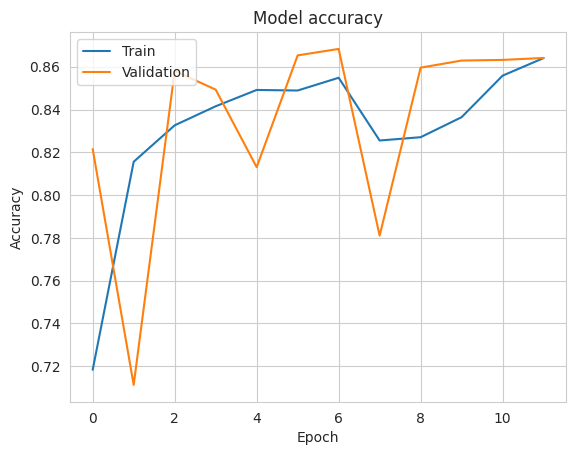

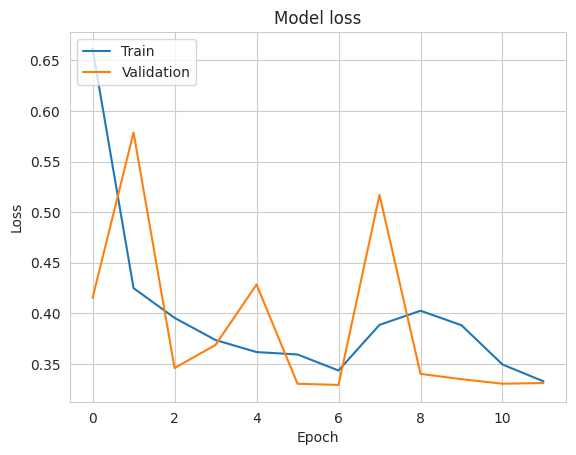

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Concatinating the history of the model
hist_1 = pd.read_csv('/kaggle/working/training_history_1.csv')
hist_2 = pd.read_csv('/kaggle/working/training_history_2.csv')
#hist_3 = pd.read_csv('/kaggle/working/training_history_3.csv')


total_hist = pd.concat([hist_1,hist_2],axis=0).reset_index()
total_hist

In [ ]:
plt.plot(total_hist['accuracy'])
plt.plot(total_hist['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(total_hist['loss'])
plt.plot(total_hist['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [39]:
test_labels = test_gen_new.classes
predictions = model.predict(test_gen_new)
predicted_classes = np.argmax(predictions, axis=1)
     

report = classification_report(test_labels, predicted_classes, target_names=list(test_gen_new.class_indices.keys()))
print(report)
     


52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 313ms/step
              precision    recall  f1-score   support

  non-tumour       0.81      0.84      0.82      1336
      tumour       0.89      0.87      0.88      1975

    accuracy                           0.85      3311
   macro avg       0.85      0.85      0.85      3311
weighted avg       0.86      0.85      0.86      3311



In [40]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

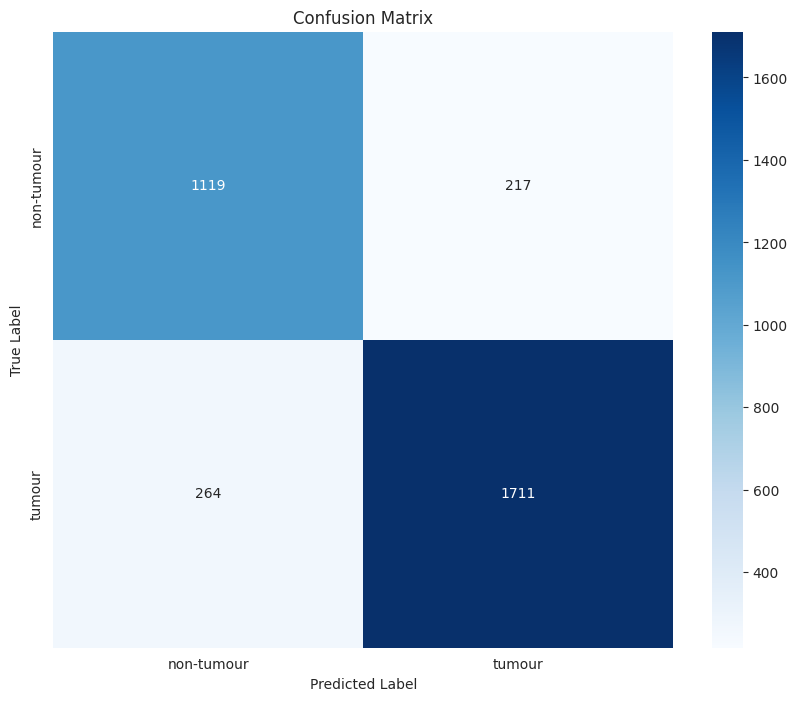

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_gen_new.class_indices.keys()), yticklabels=list(test_gen_new.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [42]:
model.save('model.h5')
model.save('model.keras')